# The undercut — Formula 1, 2026 season

**Question.** How much time does a driver actually gain by pitting *before* a rival, what does it
depend on, and does the tyre model from the [degradation study](tyre_degradation.ipynb) predict it?

**Data.** The same 2026 lap dataset (OpenF1, `data/laps_2026.parquet`). Gaps between cars are
not a separate table: they are reconstructed from the moment each car crosses the line.

**TL;DR**
1. Pitting first gains **+2.8 s** on average over the rival (95 % CI 2.0–3.2 s, bootstrap over
   races) and gains time in **81 %** of 131 pit-stop pairs.
2. Every lap the rival stays out on old tyres adds **+0.5 s**; every extra second in the pit lane
   costs **1.1 s** — almost exactly one-for-one, a sanity check of the method. Higher track
   degradation points to a bigger undercut, but with 13 races the effect is not significant.
3. As an overtaking move the undercut works when the gap is small: **~60 %** success from
   within 2 s, **44 %** from 2–3 s, **9 %** from 3–5 s.
4. The tyre model from the first study predicts the gain only modestly (correlation **0.42**,
   error 2.7 s vs 2.9 s for "always the average gain").

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

import sys; sys.path.insert(0, '..')
from analysis.clean import clean_laps
from analysis import model as M, undercut as U

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})

laps = pd.read_parquet(Path('../data/laps_2026.parquet'))
clean, _ = clean_laps(laps)
print(f'{len(laps):,} laps · {laps.race.nunique()} races')

18,405 laps · 16 races


## 1. Gaps from line-crossing times
The moment a car finishes lap *n* is the start of its lap *n + 1*. On the same lap, the difference
between two cars' crossing times is the gap between them — the same number a timing screen shows.
Checked against OpenF1's own `intervals` feed on four races (British, Belgian, Dutch, Azerbaijan;
375 gaps between adjacent cars): median difference **0.1 s**, 90 % within 0.3 s — the feed itself
updates only every few seconds.

A **pit-stop pair** is two cars within **5 s** of each other at the end of the lap before the first
one pits, where the second pits within **5 laps** and no Safety Car, VSC or red flag happens in
between. Stops more than 5 s slower than the race's median pit-lane time (penalties, repairs,
wheel problems) are not an undercut and are dropped.

`gain` = how many seconds the first car is behind the second *before* the first stop, minus the
same *after* both stop cycles are complete (end of the second car's out-lap). Positive — the first
stopper gained time.

In [2]:
all_pairs = U.pit_pairs(laps, max_lane_excess=np.inf)
pairs = U.pit_pairs(laps)
print(f'{len(all_pairs)} pairs, {len(all_pairs) - len(pairs)} with an abnormally slow stop dropped → '
      f'{len(pairs)} pairs in {pairs.race.nunique()} races')
pairs.response_laps.value_counts().sort_index().rename_axis('rival stayed out, laps').rename('pairs')

137 pairs, 6 with an abnormally slow stop dropped → 131 pairs in 13 races


rival stayed out, laps
1    50
2    26
3    22
4    19
5    14
Name: pairs, dtype: int64

### Anatomy of one undercut
The clearest case in the data: a car close behind pits, the rival stays out one more lap and
comes out behind.

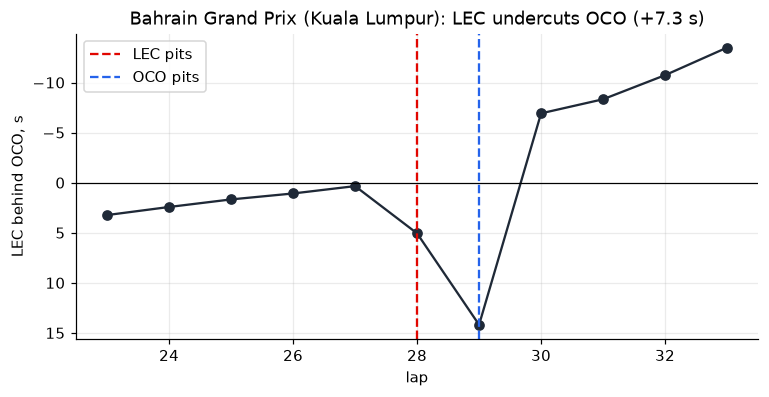

In [3]:
cross = U.crossing_times(laps)
ex = pairs[pairs.overtook & (pairs.response_laps == 1)].sort_values('gain').iloc[-1]
c = cross.loc[ex.session_key]
lap_range = range(ex.stop_lap - 5, ex.second_stop_lap + 5)
gap = (c[ex['first']] - c[ex['second']]).reindex(lap_range)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(gap.index, gap.values, 'o-', color='#1f2937')
ax.axhline(0, color='k', lw=.8)
ax.axvline(ex.stop_lap, color='#e10600', ls='--', label=f'{ex.first_driver} pits')
ax.axvline(ex.second_stop_lap, color='#2563eb', ls='--', label=f'{ex.second_driver} pits')
ax.invert_yaxis()
ax.set(xlabel='lap', ylabel=f'{ex.first_driver} behind {ex.second_driver}, s',
       title=f'{ex.race}: {ex.first_driver} undercuts {ex.second_driver} ({ex.gain:+.1f} s)')
ax.legend(); plt.show()

## 2. How much does pitting first gain?

mean gain +2.8 s (95% CI 2.0–3.2 s, bootstrap over races), median +2.7 s, gained time in 81% of pairs


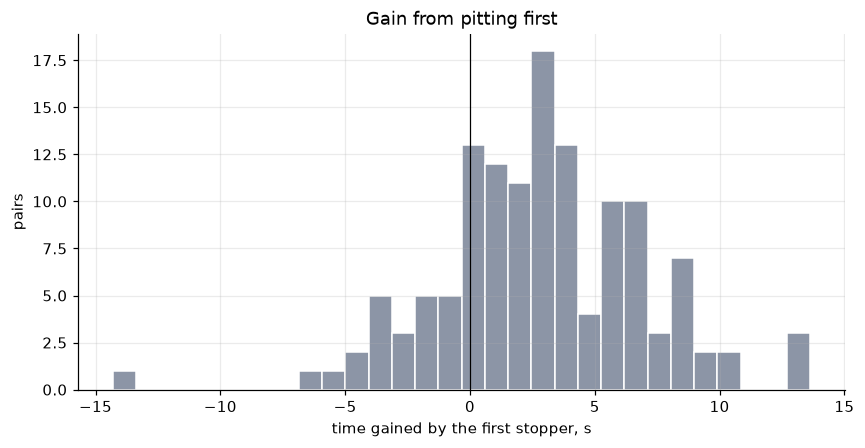

In [4]:
rng = np.random.default_rng(0)
races = pairs.race.unique()
boot = [pd.concat([pairs[pairs.race == r] for r in rng.choice(races, len(races))]).gain.mean()
        for _ in range(2000)]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'mean gain {pairs.gain.mean():+.1f} s (95% CI {lo:.1f}–{hi:.1f} s, bootstrap over races), '
      f'median {pairs.gain.median():+.1f} s, gained time in {(pairs.gain > 0).mean():.0%} of pairs')
ax = pairs.gain.plot.hist(bins=30, color='#8c95a6', edgecolor='white')
ax.axvline(0, color='k', lw=.8)
ax.set(xlabel='time gained by the first stopper, s', ylabel='pairs', title='Gain from pitting first')
plt.show()

The bootstrap resamples whole races, not single pairs: stops in the same race share track,
weather and tyre behaviour, so treating 131 pairs as independent would make the interval too narrow.

## 3. What does the gain depend on?
Linear regression of `gain` on:
* `track_deg` — degradation of the rival's old tyre compound on this track, from the per-race model of
  the first study (s/lap);
* `second_age` — age of the rival's tyres when the first car pits;
* `response_laps` — how long the rival stays out;
* `pit_lane_diff` — first car's pit-lane time minus the rival's (s; > 0 — slower stop);
* `gap_before` — how far behind the first car was.

Standard errors are clustered by race.

In [5]:
fuel = M.fuel_effect(M.fit_season(clean))[0]
models = U.race_models(clean, fuel)
pairs['track_deg'] = [models[r][0]['deg'].get(c, np.nan) if r in models else np.nan
                      for r, c in zip(pairs.race, pairs.second_old)]
reg_data = pairs.dropna(subset=['track_deg'])
reg = smf.ols('gain ~ track_deg + second_age + response_laps + pit_lane_diff + gap_before',
              reg_data).fit(cov_type='cluster', cov_kwds={'groups': reg_data.race})
print(f'{len(reg_data)} pairs, {reg_data.race.nunique()} race clusters, R² = {reg.rsquared:.2f}')
reg.summary2().tables[1][['Coef.', 'Std.Err.', 'P>|z|', '[0.025', '0.975]']]

127 pairs, 13 race clusters, R² = 0.21


,Coef.,Std.Err.,P>|z|,[0.025,0.975]
Intercept,-0.555,1.755,7.520e-01,-3.995,2.886
track_deg,15.856,9.142,8.282e-02,-2.061,33.774
second_age,0.071,0.064,2.631e-01,-0.053,0.196
response_laps,0.526,0.184,4.346e-03,0.164,0.887
pit_lane_diff,-1.142,0.285,6.136e-05,-1.700,-0.583
gap_before,-0.265,0.114,2.009e-02,-0.488,-0.042


* **Staying out costs the rival ~0.5 s per lap** — the clearest effect: the longer the
  rival runs on old tyres against fresh ones, the more the first stopper gains.
* **Pit-lane time converts one-for-one** (coefficient ≈ −1.1): a stop one second slower loses about
  one second. That is what it should be, so it also validates the gap reconstruction.
* **Track degradation** has the expected sign (on a track with 0.1 s/lap more wear the undercut is
  worth ~1.6 s more), but the interval includes zero: with 13 races there is not enough
  track-to-track variation to pin it down.
* Starting further back slightly reduces the gain, and the rival's tyre age adds little once
  the other terms are in. R² ≈ 0.2: most of the spread is traffic, driver and car-specific pace.

## 4. Does the tyre model predict the gain?
For every pair the per-race model of the first study gives a forecast: laps of fresh vs. old tyres
(`analysis/strategy.py:undercut_gain`, with the measured first-lap warm-up), the rival's own out-lap,
and the difference in pit-lane time.

127 pairs · correlation 0.42 · MAE 2.73 s (naive "average gain": 2.91 s) · bias -0.64 s


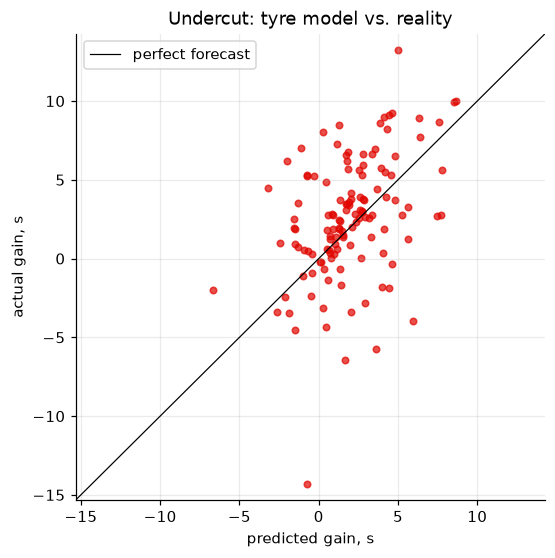

In [6]:
pairs['predicted'] = pairs.apply(U.predicted_gain, axis=1, models=models)
v = pairs.dropna(subset=['predicted'])
err = v.predicted - v.gain
naive = (v.gain - v.gain.mean()).abs().mean()
print(f'{len(v)} pairs · correlation {v[["predicted", "gain"]].corr().iloc[0, 1]:.2f} · '
      f'MAE {err.abs().mean():.2f} s (naive "average gain": {naive:.2f} s) · '
      f'bias {err.mean():+.2f} s')
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(v.predicted, v.gain, s=18, color='#e10600', alpha=.7)
lim = [min(v.predicted.min(), v.gain.min()) - 1, max(v.predicted.max(), v.gain.max()) + 1]
ax.plot(lim, lim, color='k', lw=.8, label='perfect forecast')
ax.set(xlim=lim, ylim=lim, xlabel='predicted gain, s', ylabel='actual gain, s',
       title='Undercut: tyre model vs. reality'); ax.legend()
plt.show()

The model gets the direction and rough size right, but it explains only a small part of the
spread: it knows tyres and pit-lane time, not traffic after the stop, a car stuck behind a slower
one, or a driver pushing harder on the in-lap. On average it slightly *under*-predicts the gain.

## 5. Does the undercut win the position?
Only pairs where the first stopper started behind the rival.

In [7]:
behind = pairs[pairs.gap_before > 0].copy()
behind['gap before the stop'] = pd.cut(behind.gap_before, [0, 1, 2, 3, 5],
                                       labels=['0–1 s', '1–2 s', '2–3 s', '3–5 s'])
behind.groupby('gap before the stop', observed=True).agg(
    pairs=('gain', 'size'), position_gained=('overtook', 'mean'), mean_gain_s=('gain', 'mean'))

,pairs,position_gained,mean_gain_s
gap before the stop,,,
0–1 s,10,0.600,2.897
1–2 s,16,0.625,2.868
2–3 s,16,0.438,2.673
3–5 s,33,0.091,0.987


Within two seconds the undercut takes the position in about **60 %** of cases; from 3–5 s back
it almost never does (**9 %**): the ~3 s an undercut typically gains is simply not enough.

## 6. Limitations
* **131 pairs from 13 races** of one season with a new rule set. Effects that vary between tracks
  (degradation) are estimated from only 13 clusters.
* **No traffic or dirty-air data.** A car that rejoins behind slower traffic loses the undercut;
  this is the main unexplained spread.
* **Pairs, not decisions.** Some second stops are planned, not responses; the analysis measures
  what pitting first *was worth*, not why teams chose to.
* Pit-lane time comes from OpenF1 and includes the drive through the lane; stops more than 5 s
  slower than the race median are excluded as non-standard.